# 03 Evaluation and Method Comparison

This notebook compares the baseline MLP and improved MLP if both saved model files are available.
It does not train new models.

In [6]:
from pathlib import Path
import sys

PROJECT_ROOT = Path.cwd().parent if Path.cwd().name == "notebooks" else Path.cwd()
sys.path.append(str(PROJECT_ROOT))

print("Project root:", PROJECT_ROOT)

Project root: c:\Users\tobi\Documents\Machine-Learning\ps\project_submission


In [7]:
import torch
from torch.utils.data import DataLoader
import torch.nn as nn
import pandas as pd
import matplotlib.pyplot as plt

from src.dataset import load_labels, make_label_mapping, make_transforms, SignLanguageDataset, stratified_split, compute_class_weights
from src.models import SimpleMLP, ImprovedMLP
from src.train_utils import get_device, evaluate

In [8]:
DATA_ROOT = PROJECT_ROOT / "sign_lang_train" / "sign_lang_train"

df = load_labels(DATA_ROOT)
label_to_idx, idx_to_label = make_label_mapping(df["label"])
train_df, val_df, test_df = stratified_split(df, test_size=0.2, val_size=0.2, random_state=42)

IMAGE_SIZE = 64
BATCH_SIZE = 64
eval_transform = make_transforms(image_size=IMAGE_SIZE, augment=False)

test_dataset = SignLanguageDataset(test_df, label_to_idx=label_to_idx, transform=eval_transform)
test_loader = DataLoader(test_dataset, batch_size=BATCH_SIZE, shuffle=False)

device = get_device()
print("Device:", device)

Device: cpu


In [9]:
results = []

# Baseline model
baseline_path = PROJECT_ROOT / "saved_models" / "mlp_baseline_8epochs.pt"
if baseline_path.exists():
    baseline_model = SimpleMLP(input_size=IMAGE_SIZE * IMAGE_SIZE, hidden_size=512, num_classes=len(label_to_idx)).to(device)
    baseline_model.load_state_dict(torch.load(baseline_path, map_location=device))
    baseline_criterion = nn.CrossEntropyLoss()
    baseline_result = evaluate(baseline_model, test_loader, baseline_criterion, device)
    results.append({
        "model": "MLP baseline",
        "accuracy": baseline_result["accuracy"],
        "macro_f1": baseline_result["macro_f1"],
        "weighted_f1": baseline_result["weighted_f1"],
    })
else:
    print("Missing baseline model:", baseline_path)

# Improved model
improved_path = PROJECT_ROOT / "saved_models" / "mlp_improved.pt"
if improved_path.exists():
    improved_model = ImprovedMLP(input_size=IMAGE_SIZE * IMAGE_SIZE, hidden_size=512, num_classes=len(label_to_idx), dropout=0.3).to(device)
    improved_model.load_state_dict(torch.load(improved_path, map_location=device))
    class_weights = compute_class_weights(train_df, label_to_idx).to(device)
    improved_criterion = nn.CrossEntropyLoss(weight=class_weights)
    improved_result = evaluate(improved_model, test_loader, improved_criterion, device)
    results.append({
        "model": "MLP improved",
        "accuracy": improved_result["accuracy"],
        "macro_f1": improved_result["macro_f1"],
        "weighted_f1": improved_result["weighted_f1"],
    })
else:
    print("Missing improved model:", improved_path)

results_df = pd.DataFrame(results)
results_df

,model,accuracy,macro_f1,weighted_f1
0,MLP baseline,0.696798,0.546124,0.666749
1,MLP improved,0.480888,0.435660,0.493593


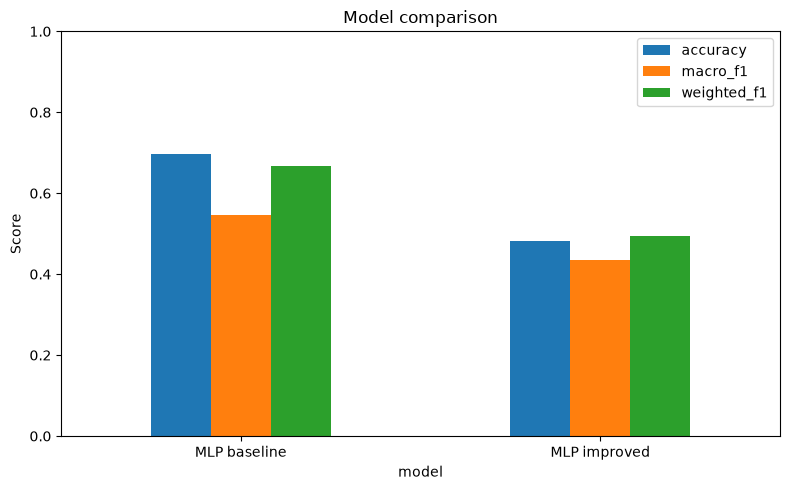

In [10]:
if len(results_df) > 0:
    (PROJECT_ROOT / "plots").mkdir(exist_ok=True)

    ax = results_df.set_index("model")[["accuracy", "macro_f1", "weighted_f1"]].plot(kind="bar", figsize=(8, 5))
    ax.set_ylim(0, 1)
    ax.set_ylabel("Score")
    ax.set_title("Model comparison")
    plt.xticks(rotation=0)
    plt.tight_layout()
    plt.savefig(PROJECT_ROOT / "plots" / "method_comparison.png", dpi=150)
    plt.show()

    results_df.to_csv(PROJECT_ROOT / "plots" / "method_comparison.csv", index=False)

## Report note

The comparison shows that the baseline MLP worked better in this run. It has about 0.69 accuracy and 0.55 macro-F1. The second MLP version has about 0.48 accuracy and 0.44 macro-F1.

The second model used dropout, class weights, data augmentation and early stopping. The validation macro-F1 increased during training, but the test result is still worse than the baseline. It looks like some rare classes improved, but the overall result got worse.

For the final submission, the baseline MLP is therefore the better model.